In [1]:
# 安裝所需套件
# Install required packages
!pip install pandas nltk

In [2]:
# 載入所有需要的套件
# Import all required libraries
import pandas as pd
import nltk
import re
import string
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

nltk.download('stopwords')
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('wordnet')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


True

In [3]:
# 讀取 CSV 資料集，並預覽基本資訊
# Load dataset and preview basic info

df = pd.read_csv('speaker_turn_data.csv')

print("總行數 / Total rows:", len(df))
print("欄位 / Columns:", df.columns.tolist())
print("開會日期數 / Unique sitting dates:", df['sittingDate'].nunique())
print("辯論題目數 / Unique titles:", df['title'].nunique())
print()
df.head()

總行數 / Total rows: 7388
欄位 / Columns: ['sittingDate', 'title', 'speaker', 'segment_no', 'speech_text']
開會日期數 / Unique sitting dates: 22
辯論題目數 / Unique titles: 2449



,sittingDate,title,speaker,segment_no,speech_text
0,22-09-2025,Election of Deputy Speakers,Mr Zaqy Mohamad,1,"Mr Speaker, I propose that Mr Christopher de S..."
1,22-09-2025,Election of Deputy Speakers,Ms Yeo Wan Ling,2,"Mr Speaker, I support the proposal."
2,22-09-2025,Retirement of Clerk of Parliament,Ms Indranee Rajah,1,"Mr Speaker, please allow me, on behalf of Memb..."
3,22-09-2025,Singapore's Support in Humanitarian Aid for Cr...,Mr Vikram Nair,1,asked the Minister for Foreign Affairs with co...
4,22-09-2025,Singapore's Support in Humanitarian Aid for Cr...,Mr Christopher de Souza,2,asked the Minister for Foreign Affairs (a) wha...


In [21]:
# 每個辯論題目只取前兩個 speaker turn（segment_no = 1 和 2）
# For each debate title, keep only the first 2 speaker turns (segment_no = 1 and 2)

df_top2 = df[df['segment_no'] <= 2].copy()

# 把同一個 title 的前兩段發言合併成一段文字
# Concatenate the first 2 turns into a single text per title
df_combined = (
    df_top2
    .groupby(['sittingDate', 'title'])['speech_text']
    .apply(lambda x: ' '.join(x.dropna().astype(str)))
    .reset_index()
)

# 把 title 本身也加進文字裡（title 含有重要關鍵詞）
# Prepend the title text to the combined speech text
df_combined['full_text'] = df_combined['title'] + ' ' + df_combined['speech_text']

# 建立 Join Key = sittingDate + title
# Create join key by combining sittingDate and title
df_combined['join_key'] = df_combined['sittingDate'] + '_' + df_combined['title']

# 過濾程序性辯論 / Filter out procedural debates
procedural_keywords = [
    'written reply', 'parliamentary question',
    'written answer', 'oral reply',
    'order paper', 'sitting date',
    'proceedings on', 'report of',
     'questions without oral answer',
    'supply reporting progress',
    'committee of supply',

]


mask = df_combined['title'].str.lower().apply(
    lambda x: not any(kw in x for kw in procedural_keywords)
)

before = len(df_combined)
df_combined = df_combined[mask].reset_index(drop=True)
after = len(df_combined)

print(f"移除程序性辯論 / Removed procedural debates: {before - after} 筆")
print(f"剩餘辯論數 / Remaining debates: {after}")
print()
print("Join Key 範例 / Sample join keys:")
print(df_combined['join_key'].head(3).tolist())
df_combined.head()

移除程序性辯論 / Removed procedural debates: 21 筆
剩餘辯論數 / Remaining debates: 2456

Join Key 範例 / Sample join keys:
['02-03-2026_AI Literacy Courses for Prison Inmates', '02-03-2026_Acceptance Rates of Revised HealthHub Terms of Use and Alternative Access Options', '02-03-2026_Adequacy of Existing Laws to Punish Egregious Road Behaviour That Result in Death']


,sittingDate,title,speech_text,full_text,join_key
0,02-03-2026,AI Literacy Courses for Prison Inmates,asked the Coordinating Minister for National S...,AI Literacy Courses for Prison Inmates asked t...,02-03-2026_AI Literacy Courses for Prison Inmates
1,02-03-2026,Acceptance Rates of Revised HealthHub Terms of...,asked the Coordinating Minister for Social Pol...,Acceptance Rates of Revised HealthHub Terms of...,02-03-2026_Acceptance Rates of Revised HealthH...
2,02-03-2026,Adequacy of Existing Laws to Punish Egregious ...,asked the Coordinating Minister for National S...,Adequacy of Existing Laws to Punish Egregious ...,02-03-2026_Adequacy of Existing Laws to Punish...
3,02-03-2026,Appropriate Assessment Models for Primary Scho...,asked the Minister for Education given growing...,Appropriate Assessment Models for Primary Scho...,02-03-2026_Appropriate Assessment Models for P...
4,02-03-2026,Barrier-free Access on Public Footpaths for Mo...,asked the Acting Minister for Transport what m...,Barrier-free Access on Public Footpaths for Mo...,02-03-2026_Barrier-free Access on Public Footp...


In [22]:
# 定義文字清理函數：移除雜訊、標點、停用詞，並做詞形還原
# Define text cleaning function: remove noise, punctuation, stopwords, and lemmatize

lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

# 加入國會文字常見但無意義的詞
# Add parliamentary-specific stopwords that carry no topic meaning
custom_stopwords = {
    'mr', 'mrs', 'ms', 'dr', 'sir', 'minister', 'member', 'parliament',
    'singapore', 'government', 'asked', 'whether', 'would', 'could',
    'also', 'said', 'may', 'will', 'shall', 'upon', 'within','speaker',
    'people', 'one', 'must'
}
stop_words = stop_words.union(custom_stopwords)

def clean_text(text):
    # 轉小寫 / Lowercase
    text = text.lower()

    # 移除非 ASCII 字元（例如 ""、—、中文字等）
    # Remove non-ASCII characters (e.g. curly quotes, em-dashes, Chinese characters)
    text = text.encode('ascii', 'ignore').decode('ascii')

    # 移除 HTML tag / Remove HTML tags
    text = re.sub(r'<[^>]+>', '', text)

    # 移除數字 / Remove numbers
    text = re.sub(r'\d+', '', text)

    # 移除標點符號 / Remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))

    # 移除多餘空格 / Remove extra whitespace
    text = re.sub(r'\s+', ' ', text).strip()

    # 分詞 / Tokenize
    tokens = word_tokenize(text)

    # 移除停用詞 + 短詞（少於3個字母）/ Remove stopwords and short words
    tokens = [t for t in tokens if t not in stop_words and len(t) > 2]

    # 詞形還原 / Lemmatize
    tokens = [lemmatizer.lemmatize(t) for t in tokens]

    return tokens

# 套用清理函數到每一行
# Apply cleaning function to each row
df_combined['cleaned_tokens'] = df_combined['full_text'].apply(clean_text)

print("清理完成 / Cleaning done!")
print()
print("範例原始文字 / Sample original text:")
print(df_combined['full_text'].iloc[2][:200])
print()
print("範例清理後 tokens / Sample cleaned tokens:")
print(df_combined['cleaned_tokens'].iloc[2])

清理完成 / Cleaning done!

範例原始文字 / Sample original text:
Adequacy of Existing Laws to Punish Egregious Road Behaviour That Result in Death asked the Coordinating Minister for National Security and Minister for Home Affairs (a) whether the Government has stu

範例清理後 tokens / Sample cleaned tokens:
['adequacy', 'existing', 'law', 'punish', 'egregious', 'road', 'behaviour', 'result', 'death', 'coordinating', 'national', 'security', 'home', 'affair', 'studied', 'adequacy', 'existing', 'law', 'punish', 'egregious', 'road', 'behaviour', 'resulting', 'death', 'consider', 'introducing', 'specific', 'offence', 'vehicular', 'homicide', 'carrying', 'penalty', 'par', 'culpable', 'homicide', 'current', 'penalty', 'considered', 'proportionate', 'serious', 'case', 'today', 'person', 'act', 'cause', 'death', 'provision', 'penal', 'code', 'charge', 'person', 'murder', 'culpable', 'homicide', 'include', 'death', 'caused', 'use', 'vehicle', 'offence', 'addition', 'driving', 'offence', 'road', 'traffic', 'act

In [23]:
# 檢查清理後的資料品質
# Inspect the quality of cleaned data

# 看看平均每個辯論有多少個 token
# Check average token count per debate
df_combined['token_count'] = df_combined['cleaned_tokens'].apply(len)

print("Token 數量統計 / Token count statistics:")
print(df_combined['token_count'].describe())
print()

# 移除 token 太少的辯論（少於 5 個 token 通常是程序性發言，沒有實質內容）
# Remove debates with too few tokens (likely procedural, no content)
before = len(df_combined)
df_combined = df_combined[df_combined['token_count'] >= 10].reset_index(drop=True)
after = len(df_combined)


print(f"移除過短辯論 / Removed short debates: {before - after} 筆")
print(f"剩餘辯論數 / Remaining debates: {after}")

Token 數量統計 / Token count statistics:
count    2456.000000
mean      135.791938
std       242.027965
min         6.000000
25%        70.000000
50%       101.000000
75%       138.000000
max      6182.000000
Name: token_count, dtype: float64

移除過短辯論 / Removed short debates: 8 筆
剩餘辯論數 / Remaining debates: 2448


In [7]:
# 安裝 gensim（LDA 的主要套件）
# Install gensim for LDA modelling
!pip install gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 82.2 MB/s eta 0:00:00


In [8]:
# 載入 gensim 相關模組
# Import gensim modules for LDA
import gensim
from gensim import corpora
from gensim.models import LdaModel
from gensim.models.coherencemodel import CoherenceModel
import matplotlib.pyplot as plt

In [24]:
# 把 tokens 轉成 gensim 可以讀的 Dictionary 和 Bag-of-Words Corpus
# Convert tokens into gensim Dictionary and Bag-of-Words Corpus

# Dictionary：把每個詞對應到一個 ID
# Dictionary: map each unique word to an integer ID
dictionary = corpora.Dictionary(df_combined['cleaned_tokens'])

print("建立前字典大小 / Dictionary size before filtering:", len(dictionary))

# 過濾太稀有或太常見的詞
# Filter out words that are too rare or too common
# no_below=5：至少出現在 5 個辯論裡的詞才保留
# no_above=0.7：出現在超過 70% 辯論裡的詞刪掉（太常見，沒區別性）
dictionary.filter_extremes(no_below=5, no_above=0.7)

print("過濾後字典大小 / Dictionary size after filtering:", len(dictionary))

# Corpus：把每個辯論的 tokens 轉成 Bag-of-Words 格式
# Corpus: convert each debate's tokens into Bag-of-Words format
corpus = [dictionary.doc2bow(tokens) for tokens in df_combined['cleaned_tokens']]

print("Corpus 大小 / Corpus size:", len(corpus))
print()
print("範例 Corpus（第一個辯論前5個詞）/ Sample corpus (first 5 words of first debate):")
print(corpus[0][:5])
print("對應的詞 / Corresponding words:")
print([(dictionary[id], freq) for id, freq in corpus[0][:5]])

建立前字典大小 / Dictionary size before filtering: 15524
過濾後字典大小 / Dictionary size after filtering: 5209
Corpus 大小 / Corpus size: 2448

範例 Corpus（第一個辯論前5個詞）/ Sample corpus (first 5 words of first debate):
[(0, 1), (1, 1), (2, 1), (3, 1), (4, 1)]
對應的詞 / Corresponding words:
[('access', 1), ('affair', 1), ('airelated', 1), ('aligned', 1), ('artificial', 1)]


In [25]:
# 測試 K = 5 到 20，找出 coherence score 最高的 K 值
# Test K from 5 to 20 to find the optimal number of topics

coherence_scores = []
k_values = range(5, 21)  # 測試 K = 5, 6, 7, ... 20

print("開始測試不同 K 值 / Testing different K values...")
print("（這可能需要幾分鐘）/ (This may take a few minutes)")
print()

for k in k_values:
    lda_model = LdaModel(
        corpus=corpus,
        id2word=dictionary,
        num_topics=k,
        random_state=42,       # 固定隨機種子，確保結果可重現 / Fix random seed for reproducibility
        passes=10,             # 訓練 10 次 / Train for 10 passes
        alpha='auto',          # 自動調整 alpha 參數 / Auto-tune alpha
        per_word_topics=True
    )

    # 計算 Coherence Score（越高越好）
    # Calculate Coherence Score (higher is better)
    coherence_model = CoherenceModel(
        model=lda_model,
        texts=df_combined['cleaned_tokens'].tolist(),
        dictionary=dictionary,
        coherence='c_v'
    )
    score = coherence_model.get_coherence()
    coherence_scores.append(score)
    print(f"K = {k:2d} | Coherence Score = {score:.4f}")

print()
print("測試完成 / Testing complete!")

開始測試不同 K 值 / Testing different K values...
（這可能需要幾分鐘）/ (This may take a few minutes)

K =  5 | Coherence Score = 0.3518
K =  6 | Coherence Score = 0.3975
K =  7 | Coherence Score = 0.4405
K =  8 | Coherence Score = 0.4109
K =  9 | Coherence Score = 0.4313
K = 10 | Coherence Score = 0.4011
K = 11 | Coherence Score = 0.4243
K = 12 | Coherence Score = 0.4284
K = 13 | Coherence Score = 0.4379
K = 14 | Coherence Score = 0.4527
K = 15 | Coherence Score = 0.4354
K = 16 | Coherence Score = 0.4850
K = 17 | Coherence Score = 0.4349
K = 18 | Coherence Score = 0.4362
K = 19 | Coherence Score = 0.4349
K = 20 | Coherence Score = 0.4515

測試完成 / Testing complete!


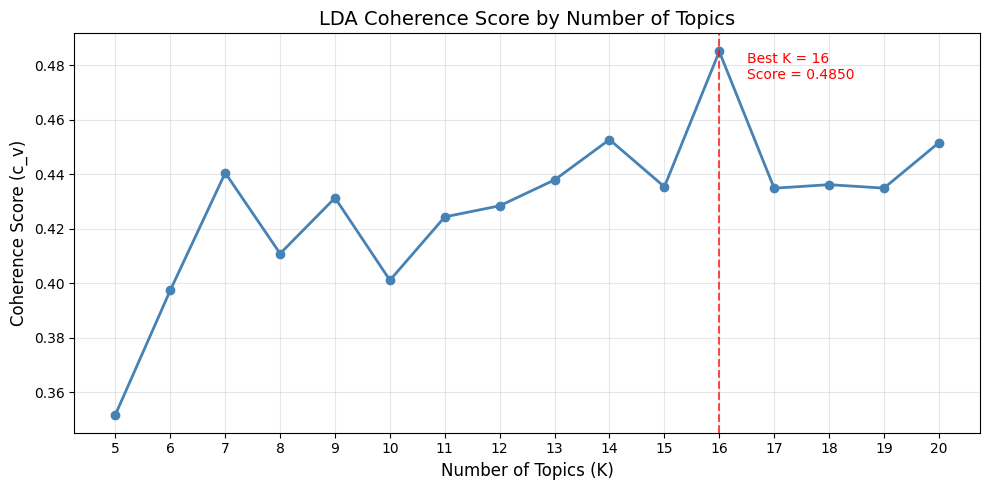

建議最佳 K 值 / Suggested best K: 16
最高 Coherence Score / Best coherence score: 0.4850


In [26]:
# 把 coherence score 畫成折線圖，幫助選擇最佳 K 值
# Plot coherence scores to help select the best K value

plt.figure(figsize=(10, 5))
plt.plot(list(k_values), coherence_scores, marker='o', color='steelblue', linewidth=2)
plt.xlabel('Number of Topics (K)', fontsize=12)
plt.ylabel('Coherence Score (c_v)', fontsize=12)
plt.title('LDA Coherence Score by Number of Topics', fontsize=14)
plt.xticks(list(k_values))
plt.grid(True, alpha=0.3)

# 標出最高分的 K 值
# Mark the K with highest score
best_k = list(k_values)[coherence_scores.index(max(coherence_scores))]
best_score = max(coherence_scores)
plt.axvline(x=best_k, color='red', linestyle='--', alpha=0.7)
plt.annotate(
    f'Best K = {best_k}\nScore = {best_score:.4f}',
    xy=(best_k, best_score),
    xytext=(best_k + 0.5, best_score - 0.01),
    fontsize=10,
    color='red'
)

plt.tight_layout()
plt.show()

print(f"建議最佳 K 值 / Suggested best K: {best_k}")
print(f"最高 Coherence Score / Best coherence score: {best_score:.4f}")

In [27]:
# 用 K = 14~16 正式訓練最終的 LDA 模型
# Train the final LDA model with K = 14~16

BEST_K = 16

print(f"正在訓練 LDA 模型，K = {BEST_K} / Training LDA model with K = {BEST_K}...")

final_lda = LdaModel(
    corpus=corpus,
    id2word=dictionary,
    num_topics=BEST_K,
    random_state=42,        # 固定隨機種子確保結果可重現 / Fix seed for reproducibility
    passes=15,              # 正式訓練用更多 passes，結果更穩定 / More passes for stable results
    alpha='auto',           # 自動調整 alpha / Auto-tune alpha
    per_word_topics=True
)

print("訓練完成！/ Training complete!")

正在訓練 LDA 模型，K = 16 / Training LDA model with K = 16...
訓練完成！/ Training complete!


In [28]:
# 提取每個 topic 的前 10 or 15 個關鍵詞
# Extract top 10 or 15 keywords for each topic

print("=" * 60)
print("各 Topic 的關鍵詞 / Top Keywords per Topic")
print("=" * 60)

topic_keywords = {}

for topic_id in range(BEST_K):
    # 取出前 15 個關鍵詞和它們的權重
    # Get top 15 keywords and their weights
    top_words = final_lda.show_topic(topic_id, topn=10)
    keywords = [word for word, prob in top_words]
    topic_keywords[topic_id] = keywords

    print(f"\nTopic {topic_id:2d}: {', '.join(keywords)}")

print()
print("=" * 60)

各 Topic 的關鍵詞 / Top Keywords per Topic

Topic  0: hdb, year, flat, development, fire, past, national, number, five, application

Topic  1: senior, support, voucher, community, singaporean, household, heartland, resident, cdc, first

Topic  2: support, worker, company, singaporean, skillsfuture, scheme, business, individual, credit, help

Topic  3: bus, transport, operator, commuter, acting, public, system, time, fare, captain

Topic  4: income, household, scheme, cpf, support, art, local, ministry, loan, culture

Topic  5: question, ministry, parliamentary, reply, september, sitting, addressed, foreign, national, election

Topic  6: road, safety, measure, work, traffic, noise, national, security, public, ministry

Topic  7: programme, industry, sector, development, local, support, technology, enterprise, training, graduate

Topic  8: development, resident, public, plan, hdb, estate, area, community, town, board

Topic  9: worker, job, work, employer, employment, workplace, manpower, car

In [29]:
# 把所有 topic 的 keywords 整理成一個 DataFrame，方便之後傳給 LLM
# Organise all topic keywords into a DataFrame for LLM naming later

keywords_df = pd.DataFrame([
    {
        'topic_id': topic_id,
        'keywords': ', '.join(keywords)
    }
    for topic_id, keywords in topic_keywords.items()
])

print("Keywords DataFrame:")
print(keywords_df.to_string(index=False))

Keywords DataFrame:
 topic_id                                                                                             keywords
        0                        hdb, year, flat, development, fire, past, national, number, five, application
        1         senior, support, voucher, community, singaporean, household, heartland, resident, cdc, first
        2      support, worker, company, singaporean, skillsfuture, scheme, business, individual, credit, help
        3                      bus, transport, operator, commuter, acting, public, system, time, fare, captain
        4                         income, household, scheme, cpf, support, art, local, ministry, loan, culture
        5 question, ministry, parliamentary, reply, september, sitting, addressed, foreign, national, election
        6                    road, safety, measure, work, traffic, noise, national, security, public, ministry
        7 programme, industry, sector, development, local, support, technology, enterprise, 

In [30]:
# 每個辯論會屬於多個 topic（各有不同機率）
# 我們取機率最高的那個作為它的 dominant topic
# Each debate has probabilities for all topics; we take the highest as dominant topic

dominant_topics = []

for i, bow in enumerate(corpus):
    # 取得這個辯論在所有 topic 的機率分佈
    # Get topic probability distribution for this debate
    topic_probs = final_lda.get_document_topics(bow, minimum_probability=0)

    # 找出機率最高的 topic
    # Find the topic with highest probability
    dominant_topic = max(topic_probs, key=lambda x: x[1])
    dominant_topics.append({
        'topic_id': dominant_topic[0],
        'topic_probability': round(dominant_topic[1], 4)
    })

# 合併回原本的 DataFrame
# Merge back into the main DataFrame
dominant_df = pd.DataFrame(dominant_topics)
df_combined['dominant_topic_id'] = dominant_df['topic_id']
df_combined['topic_probability'] = dominant_df['topic_probability']

# 看看每個 topic 分配到多少辯論
# Check how many debates are assigned to each topic
print("每個 Topic 的辯論數 / Number of debates per topic:")
print(df_combined['dominant_topic_id'].value_counts().sort_index())

每個 Topic 的辯論數 / Number of debates per topic:
dominant_topic_id
0     226
1     120
2     117
3      95
4      91
5      99
6     187
7     151
8     188
9     131
10    136
11    225
12    257
13     63
14     73
15    289
Name: count, dtype: int64


In [32]:
# Meta-topic names determined by LLM (Claude) based on top keywords
# LLM 根據 top keywords 決定的 meta-topic 名稱

topic_names = {
    0:  "Housing & Property Policy",
    1:  "Community Schemes & Senior Support",
    2:  "Workforce Support & Business Grants",
    3:  "Public Transport & Commuting",
    4:  "Household Finance & Income Support",
    5:  "Parliamentary Procedures & Foreign Affairs",
    6:  "Road Safety & Public Security",
    7:  "Industry & Enterprise Development",
    8:  "Urban Planning & Estate Development",
    9:  "Labour & Workplace Relations",
    10: "Trade, Energy & Consumer Affairs",
    11: "Healthcare & Mental Health",
    12: "Education & Child Development",
    13: "Caregiving & Family Leave",
    14: "Sports, Recreation & Community",
    15: "Law Enforcement & Online Safety"
}

print("Topic 名稱對照 / Topic Name Mapping:")
print()
for topic_id, name in topic_names.items():
    keywords_str = ', '.join(topic_keywords[topic_id])
    print(f"Topic {topic_id:2d} | {name}")
    print(f"         Keywords: {keywords_str}")
    print()

Topic 名稱對照 / Topic Name Mapping:

Topic  0 | Housing & Property Policy
         Keywords: hdb, year, flat, development, fire, past, national, number, five, application

Topic  1 | Community Schemes & Senior Support
         Keywords: senior, support, voucher, community, singaporean, household, heartland, resident, cdc, first

Topic  2 | Workforce Support & Business Grants
         Keywords: support, worker, company, singaporean, skillsfuture, scheme, business, individual, credit, help

Topic  3 | Public Transport & Commuting
         Keywords: bus, transport, operator, commuter, acting, public, system, time, fare, captain

Topic  4 | Household Finance & Income Support
         Keywords: income, household, scheme, cpf, support, art, local, ministry, loan, culture

Topic  5 | Parliamentary Procedures & Foreign Affairs
         Keywords: question, ministry, parliamentary, reply, september, sitting, addressed, foreign, national, election

Topic  6 | Road Safety & Public Security
         K

In [33]:
# 把 meta-topic label 加回 df_combined
# Add meta-topic labels back to df_combined

df_combined['meta_topic_label'] = df_combined['dominant_topic_id'].map(topic_names)

# 整理最終輸出的欄位
# Select and organise final output columns
df_output = df_combined[[
    'sittingDate',
    'title',
    'join_key',
    'dominant_topic_id',
    'meta_topic_label',
    'topic_probability'
]].copy()

print("最終輸出預覽 / Final output preview:")
print(df_output.head(10).to_string(index=False))
print()
print("總筆數 / Total records:", len(df_output))

最終輸出預覽 / Final output preview:
sittingDate                                                                                                                            title                                                                                                                                    join_key  dominant_topic_id                    meta_topic_label  topic_probability
 02-03-2026                                                                                           AI Literacy Courses for Prison Inmates                                                                                           02-03-2026_AI Literacy Courses for Prison Inmates                  7   Industry & Enterprise Development             0.3589
 02-03-2026                                                Acceptance Rates of Revised HealthHub Terms of Use and Alternative Access Options                                                02-03-2026_Acceptance Rates of Revised HealthHub Terms of Use and Alter

In [34]:
# 儲存兩份檔案
# Save two output files

# 檔案 1：主要輸出（給 Dashboard 用）
# File 1: Main output (for Dashboard)
df_output.to_csv('meta_topic_labels.csv', index=False)
print("✅ 儲存完成 / Saved: meta_topic_labels.csv")

# 檔案 2：Topic 對照表（給組員參考）
# File 2: Topic reference table (for teammates)
topic_reference = pd.DataFrame([
    {
        'topic_id': topic_id,
        'meta_topic_label': topic_names[topic_id],
        'keywords': ', '.join(keywords)
    }
    for topic_id, keywords in topic_keywords.items()
])
topic_reference.to_csv('topic_reference.csv', index=False)
print("✅ 儲存完成 / Saved: topic_reference.csv")

print()
print("Topic 對照表 / Topic Reference Table:")
print(topic_reference.to_string(index=False))

✅ 儲存完成 / Saved: meta_topic_labels.csv
✅ 儲存完成 / Saved: topic_reference.csv

Topic 對照表 / Topic Reference Table:
 topic_id                           meta_topic_label                                                                                             keywords
        0                  Housing & Property Policy                        hdb, year, flat, development, fire, past, national, number, five, application
        1         Community Schemes & Senior Support         senior, support, voucher, community, singaporean, household, heartland, resident, cdc, first
        2        Workforce Support & Business Grants      support, worker, company, singaporean, skillsfuture, scheme, business, individual, credit, help
        3               Public Transport & Commuting                      bus, transport, operator, commuter, acting, public, system, time, fare, captain
        4         Household Finance & Income Support                         income, household, scheme, cpf, support, ar

In [35]:
# 從 Colab 下載檔案到你的電腦
# Download files from Colab to your local machine
from google.colab import files

files.download('meta_topic_labels.csv')
files.download('topic_reference.csv')
print("✅ 下載完成 / Download complete!")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ 下載完成 / Download complete!
